# Quantum Cryptography

This notebook extends the tutorial sequence from quantum circuits and measurement, through the underlying mathematics and computational complexity, to a major application in security: **quantum key distribution (QKD)**. We focus on BB84, a protocol that lets two parties establish shared random key material while detecting certain forms of eavesdropping.

QKD is often described too broadly. It does not encrypt messages by itself, authenticate users automatically, or make an entire network secure. It is one possible method for distributing keys under specific physical, protocol, and implementation assumptions.

The small simulator in this notebook uses NumPy to model idealized qubit preparation and measurement. It illustrates the logic of BB84 and intercept-resend disturbance; it is not a secure cryptographic implementation and must not be used to protect data.

## Learning outcomes

You will distinguish QKD from encryption and post-quantum cryptography, explain BB84's two measurement bases, derive the ideal intercept-resend error rate, describe classical post-processing, and identify assumptions and implementation risks that security claims depend on.

## 1. What problem is quantum cryptography solving?

Cryptography provides several distinct services:

- **Confidentiality:** keep message contents secret.
- **Integrity:** detect unauthorized changes.
- **Authentication:** establish who is communicating.
- **Key establishment:** arrange shared secret key material.

BB84 addresses key establishment. Alice and Bob send quantum states over a quantum channel and discuss some information over a classical channel. If they detect too much disturbance, they abort; otherwise, classical post-processing can turn their correlated measurement data into a shorter shared key. They can then use that key with ordinary symmetric cryptography, such as an authenticated-encryption scheme.

**QKD does not provide authentication from nothing.** The classical communication must be authenticated, usually using a previously shared authentication key or a suitable public-key authentication system. Without authentication, an active attacker can perform a man-in-the-middle attack and establish separate keys with Alice and Bob.

## 2. The BB84 states

BB84 encodes each random bit using one of two bases. In the computational, or $Z$, basis, bit 0 is $|0\rangle$ and bit 1 is $|1\rangle$. In the diagonal, or $X$, basis, bit 0 is $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$ and bit 1 is $| - \rangle=(|0\rangle-|1\rangle)/\sqrt{2}$.

| Basis | Bit 0 | Bit 1 |
|---|---|---|
| $Z$ | $|0\rangle$ | $|1\rangle$ |
| $X$ | $|+\rangle$ | $| - \rangle$ |

States within one basis are orthogonal and can be distinguished perfectly by measuring in that basis. States from different bases are not orthogonal: for example, $|\langle0|+\rangle|^2=1/2$. Measuring a state in the wrong basis therefore gives a random bit in the ideal model. This is the same measurement and basis-change mathematics used in the earlier notebooks.

### Why disturbance can reveal interception

Suppose Eve intercepts a photon, chooses a random BB84 basis, measures it, and sends a new state to Bob matching her result. If Eve happened to choose Alice's basis, she learns the bit without disturbing that encoding. If she chose the other basis, her result is random; the replacement state can then disagree with Alice's bit when Bob measures in Alice's basis.

Conditioned on Alice and Bob having used the same basis, a full intercept-resend attack chooses the wrong basis with probability $1/2$. In that case Eve's measurement produces a wrong bit with probability $1/2$. Thus the expected error rate in the sifted key is $1/2\times1/2=1/4$, or 25 percent. This calculation explains one simple attack; it is not a complete proof against all attacks.

### No-cloning and measurement disturbance

The no-cloning theorem says that an unknown quantum state cannot be copied perfectly for every possible input by a physical operation. Intuitively, a unitary that copied two nonorthogonal states would have to preserve their inner product while turning distinct originals into perfectly distinguishable copies, which is impossible.

No-cloning does not mean that every attempt to learn anything about a quantum signal must cause a fixed detectable error. Security proofs quantify information gained and disturbance under a defined protocol and set of assumptions. Real attacks may exploit imperfect sources or detectors, so implementation security remains essential.

## 3. BB84 protocol, step by step

1. **Prepare:** Alice independently chooses random bits and random $Z$ or $X$ bases, then sends the corresponding quantum states.
2. **Measure:** Bob independently chooses a random basis for each received signal and records the outcomes.
3. **Sift:** Over an authenticated classical channel, they announce bases, not bit values. They keep positions where their bases match and discard the rest. With unbiased independent bases, about half the transmitted positions remain.
4. **Estimate errors:** They publicly compare a randomly chosen subset of sifted bits to estimate the quantum bit error rate (QBER). These disclosed test bits are discarded. If the error estimate is too high, they abort.
5. **Reconcile:** If they continue, classical error correction makes their remaining strings agree. The public transcript can reveal information, which must be accounted for.
6. **Amplify privacy:** They apply a suitable randomly selected hash to compress the reconciled strings. This reduces an adversary's residual information, at the cost of a shorter final key.
7. **Use the key:** The resulting key can feed a conventional symmetric encryption or authentication scheme.

The exact acceptable QBER and final key length are protocol- and implementation-dependent; they come from a security analysis, not from a universal 25 percent rule.

## 4. Simulate BB84 measurements

Represent the four BB84 states as two-component vectors. To measure in the $X$ basis, change to the $|+\rangle,| - \rangle$ basis and sample according to the Born rule. The simulator below models ideal state preparation and projective measurement, with an optional intercept-resend probability for Eve.

It keeps arrays for Alice, Eve, and Bob in ordinary Python memory. A real protocol does not hand all secret data to one program like this; the simulator is intentionally transparent so we can inspect the cause of errors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ket0 = np.array([1.0, 0.0], dtype=complex)
ket1 = np.array([0.0, 1.0], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)
bb84_states = {
    (0, 0): ket0, (0, 1): ket1,
    (1, 0): plus, (1, 1): minus,
}

def measure_bb84(state, basis, rng):
    basis_zero = bb84_states[(basis, 0)]
    probability_zero = abs(np.vdot(basis_zero, state)) ** 2
    return int(rng.random() >= probability_zero)

print("|<0|+>|^2 =", abs(np.vdot(ket0, plus)) ** 2)
assert np.isclose(abs(np.vdot(ket0, plus)) ** 2, 0.5)

|<0|+>|^2 = 0.4999999999999999


The function returns bit 0 with its Born-rule probability in the selected basis and bit 1 otherwise. The random-number generator is passed in explicitly so experiments can be reproduced by choosing a seed.

In [2]:
def run_bb84(transmissions=20_000, eve_intercept_probability=0.0, seed=1):
    rng = np.random.default_rng(seed)
    alice_bits = rng.integers(0, 2, size=transmissions)
    alice_bases = rng.integers(0, 2, size=transmissions)
    bob_bases = rng.integers(0, 2, size=transmissions)
    bob_bits = np.empty(transmissions, dtype=int)

    for index in range(transmissions):
        state = bb84_states[(alice_bases[index], alice_bits[index])]
        if rng.random() < eve_intercept_probability:
            eve_basis = int(rng.integers(0, 2))
            eve_bit = measure_bb84(state, eve_basis, rng)
            state = bb84_states[(eve_basis, eve_bit)]
        bob_bits[index] = measure_bb84(state, bob_bases[index], rng)

    sifted = alice_bases == bob_bases
    errors = alice_bits[sifted] != bob_bits[sifted]
    qber = float(errors.mean()) if errors.size else float("nan")
    return {"sifted_bits": int(sifted.sum()), "qber": qber, "sifted_fraction": float(sifted.mean())}

no_eavesdropper = run_bb84(eve_intercept_probability=0.0, seed=12)
full_intercept = run_bb84(eve_intercept_probability=1.0, seed=12)
print("No intercept-resend attack:", no_eavesdropper)
print("Full intercept-resend attack:", full_intercept)
assert no_eavesdropper["qber"] == 0.0
assert abs(full_intercept["qber"] - 0.25) < 0.02

No intercept-resend attack: {'sifted_bits': 10093, 'qber': 0.0, 'sifted_fraction': 0.50465}
Full intercept-resend attack: {'sifted_bits': 10093, 'qber': 0.2495789160804518, 'sifted_fraction': 0.50465}


With no channel noise and no eavesdropper, matching-basis results agree exactly in this ideal simulator. With full intercept-resend, the observed QBER fluctuates around 25 percent because the protocol uses random bits and bases. A real channel can also produce errors, so Alice and Bob cannot infer the cause of every error from QBER alone.

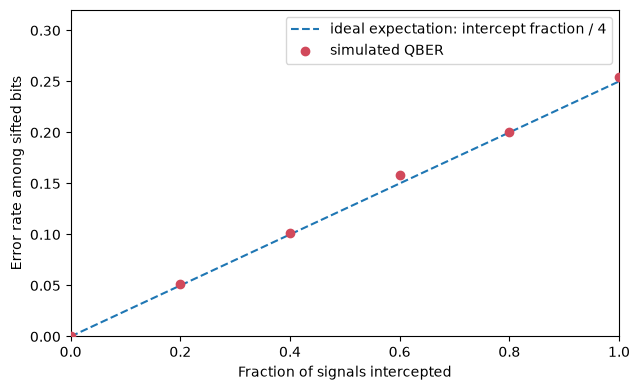

In [3]:
interception_rates = np.linspace(0.0, 1.0, 6)
observed_qber = np.array([
    run_bb84(eve_intercept_probability=float(rate), seed=100 + index)["qber"]
    for index, rate in enumerate(interception_rates)
])
ideal_qber = interception_rates / 4

figure, axis = plt.subplots(figsize=(6.5, 4))
axis.plot(interception_rates, ideal_qber, linestyle="--", label="ideal expectation: intercept fraction / 4")
axis.scatter(interception_rates, observed_qber, color="#d1495b", label="simulated QBER", zorder=3)
axis.set_xlabel("Fraction of signals intercepted")
axis.set_ylabel("Error rate among sifted bits")
axis.set_xlim(0, 1)
axis.set_ylim(0, 0.32)
axis.legend()
figure.tight_layout()
plt.show()

## 5. Finite samples and the security check

Alice and Bob do not know the exact channel error rate; they estimate it from a finite random sample of sifted positions. A point estimate alone is not enough. A security analysis uses statistical bounds to account for the possibility that the untested key positions have a higher error rate than the sample suggests. If the bound exceeds the protocol's allowed threshold, they abort.

The sample used for testing is revealed and cannot remain secret key material. Even after a favorable test, the raw sifted string is not yet a final key. Error-correction messages reveal information, and privacy amplification must compress the reconciled string enough to bound any adversary's information. The final key rate is therefore less than the fraction of signals that survived basis sifting.

### Classical post-processing

- **Parameter estimation:** disclose selected bits, estimate errors and other relevant channel statistics, then decide whether to abort.
- **Information reconciliation:** use an authenticated classical protocol to correct disagreements. This communication can leak information and must be included in the key-length calculation.
- **Privacy amplification:** apply a suitable universal hash to shorten the shared string, reducing information an adversary could retain.
- **Authentication:** protect all classical discussion from undetected modification. Authentication is a separate requirement, not a consequence of measuring qubits.

The exact steps and finite-key formulas depend on the QKD protocol and security proof. The outline here explains their roles but is not an implementation specification.

## 6. Entanglement-based QKD and E91

BB84 can be described as prepare-and-measure: Alice prepares single-qubit states and Bob measures them. In an entanglement-based protocol such as E91, a source distributes entangled pairs to Alice and Bob. Their measurements in selected bases produce correlated outcomes; a subset of other measurement settings is used to test Bell-inequality correlations.

The link to the earlier notebooks is direct: a Bell state is a joint state that cannot be factored into independent single-qubit states. The observed correlations can constrain how much information an outside party could have, under the protocol's assumptions. Entanglement alone is not a security guarantee; basis choices, authentication, finite statistics, devices, and the security proof still matter.

## 7. Security proofs meet real devices

A protocol proof is conditional on a model of sources, detectors, channels, randomness, and classical communication. Hardware can violate ideal assumptions in ways that create side channels. Examples studied in QKD include imperfect state preparation, detector efficiency mismatches, timing or wavelength leakage, and photon-number-splitting attacks on weak coherent-pulse implementations. Countermeasures include carefully characterized hardware, decoy-state protocols, monitoring, and security proofs tailored to the implementation.

Device-independent QKD aims to base security on observed nonclassical correlations rather than trusting a detailed device model. It has demanding experimental requirements, including loophole-aware Bell tests and high-quality detection; it is not a simple software setting that makes arbitrary hardware safe.

QKD also has engineering constraints: quantum signals suffer loss, practical distance and rate are limited, and extending networks may require trusted nodes or advanced quantum repeaters. Deployment decisions must consider the whole system, not just the ideal protocol.

## 8. QKD is not post-quantum cryptography

**Post-quantum cryptography (PQC)** refers to classical cryptographic algorithms designed to resist attacks by both classical and quantum computers. They run on ordinary computers and communicate over ordinary networks. **QKD** uses quantum states and requires a quantum communication channel plus authenticated classical communication.

Shor's algorithm, discussed in the computational-theory notebook, gives a polynomial-time quantum algorithm for factoring and discrete logarithms in the fault-tolerant model. This threatens widely deployed RSA and elliptic-curve public-key systems if a sufficiently capable cryptographically relevant quantum computer becomes available. PQC migration replaces vulnerable algorithms in software and protocols; QKD is a separate key-distribution option with specialized infrastructure.

| Property | QKD | Post-quantum cryptography |
|---|---|---|
| Main mechanism | Quantum-state transmission and measurement | Classical algorithms based on different mathematical problems |
| Network requirement | Quantum link plus authenticated classical channel | Ordinary digital communication |
| Typical role | Establish shared symmetric key material | Key establishment, signatures, and other public-key functions |
| Deployment constraint | Specialized optical hardware, distance and rate limits | Software and protocol updates; classical hardware |

They address related risks through different mechanisms. Neither eliminates the need for good endpoint security, correct implementation, authentication, and key management.

## 9. Quantum random-number generation

A quantum measurement can produce outcomes that are intrinsically probabilistic according to quantum theory. A quantum random-number generator (QRNG) uses a physical quantum process to generate random bits. This is related to cryptography because keys need unpredictable randomness, but QRNGs and QKD solve different problems: a QRNG generates local random values, while QKD establishes correlated key material between distant parties.

A deployed QRNG still needs engineering controls, entropy estimation, health tests, and appropriate conditioning. Calling a source quantum does not by itself guarantee that its output is unbiased, independent, or securely integrated into a cryptographic system.

## Try It

1. Alice sends $|+\rangle$ and Bob measures in the $Z$ basis. What is the probability of each bit outcome?
2. Derive the 25 percent sifted-key error rate for full intercept-resend in BB84.
3. If Alice and Bob transmit 10,000 signals with unbiased independent bases, approximately how many positions survive basis sifting before test-bit removal?
4. Why must Alice and Bob authenticate their classical discussion even if the quantum channel is ideal?
5. What does privacy amplification do, and why is error-correction leakage relevant?
6. State one key difference between QKD and post-quantum cryptography.

## Answers

1. $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$, so measurement in the $Z$ basis yields 0 and 1 with probability $1/2$ each.

2. Among sifted positions, Eve chooses the wrong basis with probability $1/2$. Given a wrong basis, her result is random and is wrong relative to Alice's bit with probability $1/2$. The product is $1/4=25\%$.

3. Alice and Bob choose matching bases with probability $1/2$, so about 5,000 positions survive sifting on average, before they reveal test bits or account for channel losses.

4. Without authentication, an active attacker can impersonate each party to the other, relay quantum signals, and create separate keys. The quantum channel alone does not establish who is at the other endpoint.

5. Privacy amplification hashes the reconciled shared string into a shorter key that limits an adversary's residual information. Error-correction messages may reveal information about the raw key, so that leakage must be included when choosing how much to compress.

6. QKD relies on a quantum communication link to distribute key material; post-quantum cryptography uses classical algorithms on ordinary networks that are designed to resist quantum-computer attacks.

## Summary

BB84 uses nonorthogonal quantum states and basis-dependent measurement so that certain attempts to learn the encoded information introduce detectable disturbance. Alice and Bob sift matching-basis outcomes, test a sample, reconcile errors, and apply privacy amplification; the classical channel must be authenticated throughout.

QKD is a key-establishment method, not encryption or complete network security. Its guarantees depend on a stated threat model, finite-key analysis, and implementation assumptions. It differs from post-quantum cryptography, which runs on classical hardware and ordinary networks. The shared theme with the earlier notebooks is that quantum mechanics supplies useful physical constraints, while algorithm analysis and engineering determine what those constraints can safely deliver.